# Routing App - Preprocessing

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import osmnx as ox
import networkx as nx
import numpy as np
import json
from geopy.distance import geodesic
from kneed import KneeLocator
from sklearn.preprocessing import MinMaxScaler

This notebook contains the preprocessing part of the prototype. It starts with two dataframes (pre-processed TripAdvisor Data and accommodation data at municipal level). I then merge them, spatially join attractions to the municipalities, filter the attractions, compute a score for each, get the OSMnx network, match the attractions with the nodes in the road network, create a distance matrix and save everything to be loaded into the next notebook. I will do this in nine steps.

## Step 1 - Loading in the relevant datasets

In [2]:
# read in tripadvisor data and split categories

tripadvisor_attractions_df = gpd.read_file('tripadvisor_attractions_geo_prepared.geojson')
tripadvisor_attractions_df['category'] = tripadvisor_attractions_df['category'].str.split('•').apply(lambda x: [i.strip() for i in x] if isinstance(x, list) else x)
tripadvisor_attractions_df['group'] = tripadvisor_attractions_df['group'].str.split('•').apply(lambda x: [i.strip() for i in x] if isinstance(x, list) else x)

In [3]:
tripadvisor_attractions_df.head(1)

,name,link,rating,review_count,category,address,latitude,longitude,X_metres,Y_metres,lbls,group,geometry
0,Hallgrimskirkja,https://www.tripadvisor.com/Attraction_Review-...,4.4,23266,[Churches & Cathedrals],"Hallgrimstorgi 1, Reykjavik 101 Iceland",64.14197,-21.92697,357552.558789,407644.449904,0,[Sightseeing],POINT (-21.92697 64.14197)


In [4]:
len(tripadvisor_attractions_df)

951

<Axes: >

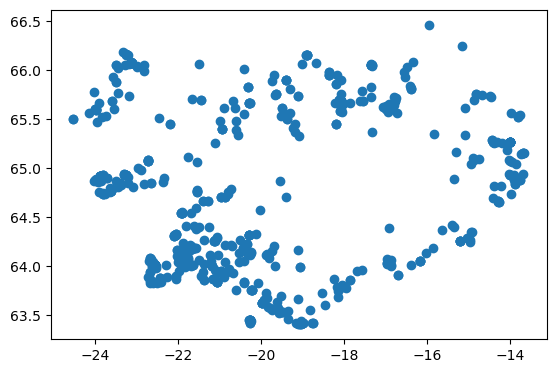

In [5]:
tripadvisor_attractions_df.plot()

In [6]:
tripadvisor_attractions_df.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [7]:
# read in accommodation data by municipality

overnight_muni_df = gpd.read_file('iceland_overnight_geo_df.geojson')

In [8]:
overnight_muni_df.head(1)

,municipality,nrsveitarfelags,stjornsyslusvaedi,nights,population,area_km2,stays_per_pop,stays_per_area,geometry
0,Akraneskaupstadur,3000,4,34131.0,8071,10.229906,4.228844,3336.394327,GEOMETRYCOLLECTION (POLYGON ((350015.715 42622...


In [9]:
len(overnight_muni_df)

62

<Axes: >

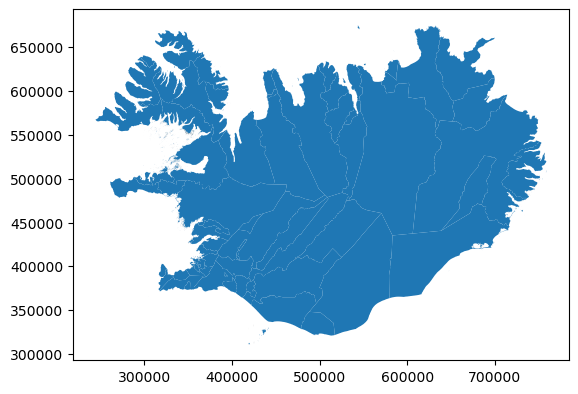

In [10]:
overnight_muni_df.plot()

In [11]:
overnight_muni_df.crs

<Projected CRS: EPSG:3057>
Name: ISN93 / Lambert 1993
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: Iceland - onshore and offshore.
- bounds: (-30.87, 59.96, -5.55, 69.59)
Coordinate Operation:
- name: Iceland Lambert 1993
- method: Lambert Conic Conformal (2SP)
Datum: Islands Net 1993
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [12]:
overnight_muni_df = overnight_muni_df.to_crs(4326)

In [13]:
overnight_muni_df.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [14]:
overnight_muni_df.columns

Index(['municipality', 'nrsveitarfelags', 'stjornsyslusvaedi', 'nights',
       'population', 'area_km2', 'stays_per_pop', 'stays_per_area',
       'geometry'],
      dtype='object')

## Step 2: Spatially join attractions to municipality polygons

In [15]:
# spatially join the two dataframes

merged_attractions_df = gpd.sjoin(
    tripadvisor_attractions_df,
    overnight_muni_df,
    how='left',
    predicate='within'
)

In [16]:
len(merged_attractions_df)

951

In [17]:
merged_attractions_df.columns

Index(['name', 'link', 'rating', 'review_count', 'category', 'address',
       'latitude', 'longitude', 'X_metres', 'Y_metres', 'lbls', 'group',
       'geometry', 'index_right', 'municipality', 'nrsveitarfelags',
       'stjornsyslusvaedi', 'nights', 'population', 'area_km2',
       'stays_per_pop', 'stays_per_area'],
      dtype='object')

In [18]:
merged_attractions_df.head(1)

,name,link,rating,review_count,category,address,latitude,longitude,X_metres,Y_metres,...,geometry,index_right,municipality,nrsveitarfelags,stjornsyslusvaedi,nights,population,area_km2,stays_per_pop,stays_per_area
0,Hallgrimskirkja,https://www.tripadvisor.com/Attraction_Review-...,4.4,23266,[Churches & Cathedrals],"Hallgrimstorgi 1, Reykjavik 101 Iceland",64.14197,-21.92697,357552.558789,407644.449904,...,POINT (-21.92697 64.14197),37.0,Reykjavikurborg,0.0,4.0,3218190.0,136894.0,244.19439,23.508627,13178.803966


In [19]:
# checking how many attractions did not get matched to a municipality
merged_attractions_df['municipality'].isna().sum()

13

In [20]:
# merged_attractions_df[merged_attractions_df['municipality'].isna()]

There are 13 attractions that did not get joined to a municipality above. To still be able to use them, I will separate them from the rest and use sjoin_nearest to join them as well as possible.

In [21]:
# first separating those that got matched and those that did not
matched = merged_attractions_df[merged_attractions_df['municipality'].notna()]

unmatched = merged_attractions_df[merged_attractions_df['municipality'].isna()].drop(
    columns=['index_right', 'municipality', 'nrsveitarfelags', 'stjornsyslusvaedi', 
             'nights', 'area_km2', 'population', 'stays_per_pop', 'stays_per_area']
)

In [22]:
unmatched.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [23]:
# based on warning, it is best to reproject to metric CRS for accurate nearest distance calculation
unmatched_projected = unmatched.to_crs(epsg=3057)
municipalities_projected = overnight_muni_df.to_crs(epsg=3057)

In [24]:
# use sjoin_nearest to join the unmatched one to the nearest municipality
# then reproject to the original CRS
nearest = gpd.sjoin_nearest(
    unmatched_projected,
    municipalities_projected,
    how='left'
).to_crs(epsg=4326)

In [25]:
# now I can combine them again

merged_attractions_df = pd.concat([matched, nearest]).sort_index()

In [26]:
len(merged_attractions_df)

951

In [27]:
merged_attractions_df['municipality'].isna().sum()

0

Now all attractions have successfully been matched!

In [28]:
# checking if matches based on the nearest join make sense

previously_unmatched_idx = [13, 24, 147, 158, 247, 249, 441, 619, 711, 811, 854, 913, 914, 928]
print(merged_attractions_df.loc[previously_unmatched_idx, ['name', 'municipality']])

                                      name                municipality
13             Víkurfjara Black Sand Beach              Myrdalshreppur
24                       Reynisfjara Beach              Myrdalshreppur
147  Caves Of Laugarvatn (the Cave People)               Blaskogabyggd
158          Reykjavik Family park and Zoo             Reykjavikurborg
247  The Transportation Museum at Ystafell             Thingeyjarsveit
249                      The French Museum                 Fjardabyggd
441                     Information Centre                   Mulathing
619               Stokkseyri Swimming Pool       Sveitarfelagid Arborg
711                French sailors cemetery             Reykjavikurborg
811                              Fagrifoss             Reykjavikurborg
854              Bokaverzlun Breidafjardar       Sveitarfelagid Arborg
913                        Dyngjan Gallery               Snaefellsbaer
914                        Lyngfellisdalur          Grundarfjardarbaer
928   

Looks good. Hólmavíkurkirkja seems to be incorrect, already based on the coordinates in the check above. As this is a prototype, I will not further investigate.

In [29]:
merged_attractions_df.columns

Index(['name', 'link', 'rating', 'review_count', 'category', 'address',
       'latitude', 'longitude', 'X_metres', 'Y_metres', 'lbls', 'group',
       'geometry', 'index_right', 'municipality', 'nrsveitarfelags',
       'stjornsyslusvaedi', 'nights', 'population', 'area_km2',
       'stays_per_pop', 'stays_per_area'],
      dtype='object')

In [30]:
# cleaning up unneeded columns  and resetting index before moving forward
merged_attractions_df = merged_attractions_df.drop(columns=['index_right', 'lbls'])

merged_attractions_df = merged_attractions_df.reset_index(drop=True)

In [31]:
merged_attractions_df.shape

(951, 20)

## Step 3 - Retrieve and save road network

In [32]:
# to avoid including F-roads or other roads that are difficult to access on my road network, I will exclude F roads by ref and roads only
# accesible with 4x4
# cf = '["highway"~"motorway|trunk|primary|secondary|tertiary"]["ref"!~"F.*"]["4wd_only"!="yes"]'
# G = ox.graph_from_place("Iceland", network_type='drive', custom_filter=cf)

In [33]:
# ox.save_graphml(G, filepath='iceland_drive_accessible.graphml')

In [34]:
G = ox.load_graphml('iceland_drive_accessible.graphml')

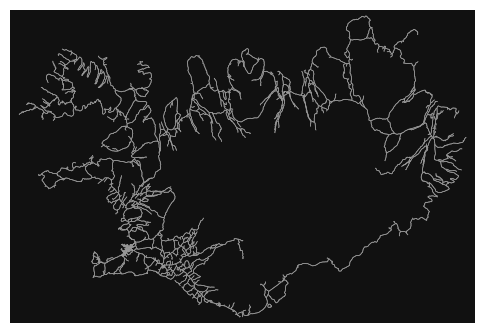

In [35]:
fig, ax = ox.plot_graph(G, figsize=(6, 5), node_size=0, edge_linewidth=0.5)

In [36]:
# I will need the undirected graph only for my prototype
G_undirected = ox.convert.to_undirected(G)

In [37]:
# to avoid issues later, I need to check if my road network is fully connected
nx.number_connected_components(G_undirected)

1

## Step 4 - Match attractions with nearest nodes/road network

In [38]:
# this makes it easier to use the coordinates to later find the nearest node of the network to match them to

# extracting x and y for each attraction
merged_attractions_df['x'] = merged_attractions_df.geometry.x
merged_attractions_df['y'] = merged_attractions_df.geometry.y

# Snap each attraction to nearest node
merged_attractions_df['node_id'] = ox.nearest_nodes(
    G_undirected,
    X=merged_attractions_df['x'],
    Y=merged_attractions_df['y']
)

In [39]:
# Keflavik Airport will be the starting point of all routes, so it needs to be added as well

keflavik_coords = (-22.6056, 63.9850)

keflavik_node = ox.nearest_nodes(
    G_undirected,
    X=keflavik_coords[0],
    Y=keflavik_coords[1]
)

Before moving forward with this, I need to check if the matching went well.

In [40]:
# some attractions might be on islands or related to bodies of water which can cause issues when snapping them to the nearest node in
# the road network
# to avoid issues with routing later, we have to check and prevent this here

# Add snapped node coordinates to check for water/island snapping errors
merged_attractions_df['snapped_lat'] = merged_attractions_df['node_id'].apply(lambda n: G_undirected.nodes[n]['y'])
merged_attractions_df['snapped_lon'] = merged_attractions_df['node_id'].apply(lambda n: G_undirected.nodes[n]['x'])

# now I can check how far the snapped location is from the location retrieved from tripadvisor, using geodesic distance

# Compute snap error in km
merged_attractions_df['snap_error_km'] = merged_attractions_df.apply(
    lambda row: geodesic(
        (row.geometry.y, row.geometry.x),
        (row['snapped_lat'], row['snapped_lon'])
    ).km, axis=1
)

I am considering implementing a threshold to remove those attractions that were snapped incorrectly across water etc. In Iceland, this issue is mainly due to fjords and some other bodies of water. Most fjords are a few kilometers wide. A threshold of around 10km might make sense to ensure there are no incorrectly snapped ones but loose as little attractions as possible.

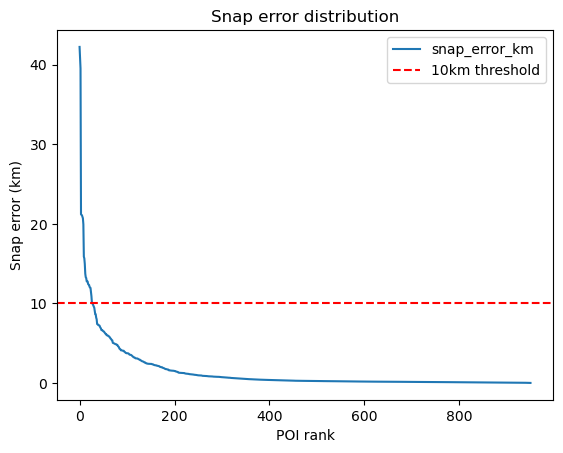

In [41]:
# plotting snapping errors to see how to filter/remove them

merged_attractions_df['snap_error_km'].sort_values(ascending=False).reset_index(drop=True).plot()
plt.axhline(y=10, color='red', linestyle='--', label='10km threshold')
plt.xlabel('POI rank')
plt.ylabel('Snap error (km)')
plt.title('Snap error distribution')
plt.legend()
plt.show()

In [42]:
# I can also check how many attractions are above a certain thresholds to get a better idea

print(f"POIs with snap error > 10km: {(merged_attractions_df['snap_error_km'] > 10).sum()}")
print(f"POIs with snap error > 5km: {(merged_attractions_df['snap_error_km'] > 5).sum()}")
print(f"POIs with snap error > 1km: {(merged_attractions_df['snap_error_km'] > 1).sum()}")

POIs with snap error > 10km: 27
POIs with snap error > 5km: 72
POIs with snap error > 1km: 246


In [43]:
# merged_attractions_df[merged_attractions_df['snap_error_km'] > 10]

In [44]:
# Remove attractions that snapped across water (islands, sea coordinates)
merged_attractions_df = merged_attractions_df[
    merged_attractions_df['snap_error_km'] <= 10].copy()

In [45]:
print(f"POIs after snap error filter: {len(merged_attractions_df)}")

POIs after snap error filter: 924


## Step 5 - Initial filter for attractions

The main idea of my project is to lead people to less popular attractions on their routes when visiting Iceland. Since I do not have access to visitor numbers for all (or basically any) attractions, I am using TripAdvisor review counts as a proxy. 
The idea is to find a threshold where attractions clearly are less popular.

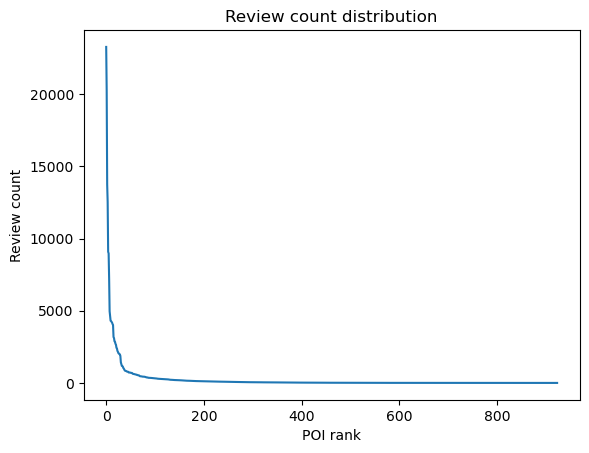

In [46]:
# find a natural break in the distribution of attraction popularity to exclude points

merged_attractions_df['review_count'].sort_values(ascending=False).reset_index(drop=True).plot()
plt.xlabel('POI rank')
plt.ylabel('Review count')
plt.title('Review count distribution')
plt.show()

Looks like a pretty steep curve. I can find the point of maximum curverture to use as a cut off. This is a simplified solution for my prototype. Classyfing attractions and places as too popular is not easy and usually requires a lot of context. Due to the scope of this project, I will settle for this point to use as a threshold as a proxy for when a place is too busy.

In [47]:
# using KneeLocator to find the point of maximum curvature 
sorted_reviews = merged_attractions_df['review_count'].sort_values(ascending=False).reset_index(drop=True)

kneedle = KneeLocator(
    x=sorted_reviews.index,
    y=sorted_reviews.values,
    curve='convex',
    direction='decreasing'
)

print(f"Knee at rank: {kneedle.knee}")
print(f"Review count threshold: {sorted_reviews[kneedle.knee]}")

Knee at rank: 38
Review count threshold: 864


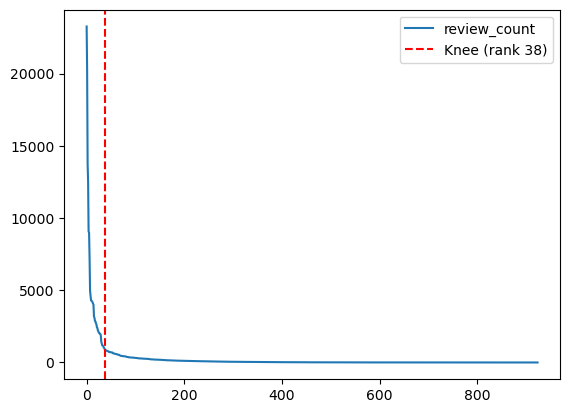

In [48]:
# Plot
sorted_reviews.plot()
plt.axvline(x=kneedle.knee, color='red', linestyle='--', label=f'Knee (rank {kneedle.knee})')
plt.legend()
plt.show()

In [49]:
# based on this, exclude all attractions (38) with more than 864 reviews 
alternative_attractions_df = merged_attractions_df.loc[(merged_attractions_df['review_count'] <= 864)].copy()

In [50]:
len(alternative_attractions_df)

886

In [51]:
alternative_attractions_df.head(1)

,name,link,rating,review_count,category,address,latitude,longitude,X_metres,Y_metres,...,population,area_km2,stays_per_pop,stays_per_area,x,y,node_id,snapped_lat,snapped_lon,snap_error_km
39,Solheimajokull Glacier,https://www.tripadvisor.com/Attraction_Review-...,4.7,864,[Geologic Formations],NaN,63.534584,-19.356466,482263.853808,336679.637255,...,881.0,749.097377,504.867196,593.765261,-19.356466,63.534584,3762059788,63.530635,-19.370975,0.845461


## Step 6 - Creating a distance matrix for all attractions 

Next, we will create a distance matrix using the road network to get the driving distances between all points. I will need this for routing to decide on what points can fit into a day, and to ensure the user can return to the airport.

In [52]:
# keflavik + all attraction nodes
poi_nodes = alternative_attractions_df['node_id'].tolist()
all_nodes = [keflavik_node] + poi_nodes

# Compute shortest path lengths between all pairs 
distance_matrix = {}
for node in all_nodes:
    lengths = nx.single_source_dijkstra_path_length(G_undirected, node, weight='length')
    distance_matrix[node] = {n: lengths.get(n, np.inf) for n in all_nodes}

# make a dataframe for easier handling
dist_df = pd.DataFrame(distance_matrix).T.reindex(index=all_nodes, columns=all_nodes)

In [53]:
# Save 
dist_df.to_csv('distance_matrix.csv')

In [54]:
# check if it looks good

print(dist_df.shape)
print("Diagonal zeros:", (np.diag(dist_df.values) == 0).all())

(887, 887)
Diagonal zeros: True


In [55]:
inf_count = (dist_df == np.inf).sum().sum()
print(f"Inf values: {inf_count}")

Inf values: 0


In [56]:
dist_df.iloc[:5, :5]

,5174792758,3762059788,4336582800,2925945013,6370763411
5174792758,0.000,200046.373,361963.024,45008.456,114356.299
3762059788,200046.373,0.000,170571.757,162400.732,222450.044
4336582800,361963.024,170571.757,0.000,324317.383,384366.695
2925945013,45008.456,162400.732,324317.383,0.000,74394.664
6370763411,114356.299,222450.044,384366.695,74394.664,0.000


The matrix mostly looks good, with 886 attractions and the airport in it, diagonal zeros and no infinite distances. 

One risk is that since some attractions are very close, they might have snapped to the same node in the road network. We need to check this to avoid issues in routing later on.

In [57]:
print(f"Duplicate rows: {dist_df.index.duplicated().sum()}")
print(f"Duplicate columns: {dist_df.columns.duplicated().sum()}")

Duplicate rows: 411
Duplicate columns: 411


In [58]:
# check a few manually 
duplicated_nodes = dist_df.index[dist_df.index.duplicated(keep=False)].unique()

In [59]:
# See which POIs share these nodes
print(alternative_attractions_df[alternative_attractions_df['node_id'].isin(duplicated_nodes)][['name', 'node_id']].sort_values('node_id'))

                                                  name      node_id
407                                   Graeni Hatturinn     12978784
437                                Akureyri Art Museum     12978784
715                                       Seal Lookout     12978784
643                                          Fold Anna     12978784
454                   Vadlaheidargöng Tunnel On Road 1     12978784
..                                                 ...          ...
223  Rokksafn Íslands - The Icelandic Museum of Roc...  13011704331
272                                         Laugar Spa  13470764062
416                 World Class Iceland fitness center  13470764062
727                                      Paint Iceland  13762193879
51                                 Kirkjufell Mountain  13762193879

[589 rows x 2 columns]


Upon manually checking the first four rows, the attractions do not appear to be close. I have to look further into this to see if the problem is messy data (incorrect geolocations retrieved from tripadvisor) or incorrect snapping.

In [60]:
alternative_attractions_df[alternative_attractions_df['node_id'] == 12978784][['name', 'geometry', 'snap_error_km']]

,name,geometry,snap_error_km
330,Ölstofa Akureyrar,POINT (-18.09144 65.68027),0.113826
407,Graeni Hatturinn,POINT (-18.08960 65.68133),0.048586
437,Akureyri Art Museum,POINT (-18.09140 65.68062),0.093254
454,Vadlaheidargöng Tunnel On Road 1,POINT (-18.08993 65.68095),0.021257
504,Linda Ola - Studio & Gallery,POINT (-18.09061 65.68142),0.077926
511,Flóra Menningarhús - Culture House Sigurhæðir,POINT (-18.08977 65.67978),0.125235
643,Fold Anna,POINT (-18.09008 65.68156),0.078820
715,Seal Lookout,POINT (-18.09131 65.68030),0.107060
747,Þingeyrakirkja,POINT (-18.08945 65.68118),0.031612


The geometry shows that they are in almost the same place. Manually checking, I can see that all but three of them actually are. The issue with the other three must be in the data itself. This is a limitation of the data I am using. For now and because I cannot investigate all instances manually, I need to work under the assumption that these are in fact different attractions in the same place. Therefore, I need to deduplicate the matrix, so that each node location is unique. I am keeping all attractions, since they are in the attractions df.

In [61]:
dist_df = dist_df[~dist_df.index.duplicated(keep='first')]
dist_df = dist_df.loc[:, ~dist_df.columns.duplicated(keep='first')]

In [62]:
# one other note: I need the indexes of the distances to be integers to work with, so I need to make sure they are, 
# in case I rerun the notebook
if not isinstance(dist_df.index[0], (int, np.integer)):
    dist_df.index = dist_df.index.astype(int)
    dist_df.columns = dist_df.columns.astype(int)
    print("Converted index and columns to int")
else:
    print("Index already int, no conversion needed")

Index already int, no conversion needed


In [63]:
# finally, I can check some distances to see if they are realistic

# distance from Keflavik to all attractions
kef_distances = dist_df.loc[keflavik_node].drop(keflavik_node)

# furthest distance
furthest_node = kef_distances.idxmax()
furthest_poi = alternative_attractions_df[alternative_attractions_df['node_id'] == furthest_node].iloc[0]
print(f"Furthest POI: {furthest_poi['name']}, {kef_distances.max()/1000:.1f} km")

# nearest distance
nearest_node = kef_distances.idxmin()
nearest_poi = alternative_attractions_df[alternative_attractions_df['node_id'] == nearest_node].iloc[0]
print(f"Nearest POI: {nearest_poi['name']}, {kef_distances.min()/1000:.1f} km")

Furthest POI: Páskahellir Cave, 732.8 km
Nearest POI: SelfossBíó, Cinema, 2.2 km


This seems plausible, the cave is on the eastern coast of Iceland, and the Kef spa is in Keflavik near the airport.

This means that now I have a distance matrix between all my attractions that I can use for routing.

## Step 7: Compute 'Hidden Gem' score per attraction

While I am already avoiding the most popular and likely overvisited attractions by filtering out the top attractions from tripadvisor, I also want to take into account that certain areas are overall visited disproportionally much, as supported by my choropleth map of overnight stays per municipality.
Therefore, I want to created a 'hidden gem' score per attraction, which I can use in the routing process to nudge the route towards less popular areas AND less popular attractions. My idea is to create a composite score of both of these indicators (review and overnight stays), using normalized log transformed metrics to ensure the impact of the skewed distribution of popularity is not overwhelming, and the two metrics can be used together despite different scales. For the overnight stays, I have decided to use overnight stays per population (also sometimes referred to as tourism intensity). 

(see https://tourism-dashboard.ec.europa.eu/map-view?lng=en&ctx=tourism&ts=TOURISM&is=TOURISM&tl=0&i=277&cl=tourism&clc=socio-economic-vulnerability&db=661&it=outline&pil=indicator-level&date=2023&tv=2021&pn=indicator-level&dblts=661&cwt=bar-chart for context of indicator).

In [64]:
# I log transform the relevant columns, and adding constant to avoid issues with zero or low values
alternative_attractions_df['log_reviews'] = np.log(alternative_attractions_df['review_count'] + 1)
alternative_attractions_df['log_stays_per_pop'] = np.log(alternative_attractions_df['stays_per_pop'] + 1)

In [65]:
# next I normalize the relevant columns
scaler = MinMaxScaler()
alternative_attractions_df['norm_reviews'] = scaler.fit_transform(alternative_attractions_df[['log_reviews']])
alternative_attractions_df['norm_stays'] = scaler.fit_transform(alternative_attractions_df[['log_stays_per_pop']])

In [66]:
# now I can compute the hidden gem score, which will be 1 minus the normalized log transformed review count plus
# the normalized log transformed stays per population divided by two

# this is because I want the hidden gem score to be high if there are few reviews and stays

alternative_attractions_df['hiddengem_score'] = (
    (1 - alternative_attractions_df['norm_reviews']) + 
    (1 - alternative_attractions_df['norm_stays'])
) / 2

In [67]:
print(f"Score range: {alternative_attractions_df['hiddengem_score'].min():.2f} - {alternative_attractions_df['hiddengem_score'].max():.2f}")
print(f"Score mean: {alternative_attractions_df['hiddengem_score'].mean():.2f}")
print(f"Score median: {alternative_attractions_df['hiddengem_score'].median():.2f}")

Score range: -0.00 - 1.00
Score mean: 0.54
Score median: 0.55


In [68]:
# Checking some examples - high scoring (most alternative)
print(alternative_attractions_df.nlargest(10, 'hiddengem_score')[['name', 'municipality', 'review_count', 'stays_per_pop', 'hiddengem_score']])

                                         name             municipality  \
865  Ullarverið - Icelandic Woolmarket & Mill        Seltjarnarnesbaer   
939         Gallerý Gimli Icelandic Handkraft        Seltjarnarnesbaer   
695                       Seltjarnarneskirkja        Seltjarnarnesbaer   
773              Kraftlyftingafélag Akureyrar              Horgarsveit   
852                                      Þúfa             Kopavogsbaer   
877                       Walter Mitty Bridge             Kopavogsbaer   
602   Medical and Health Care Museum Nesstofa        Seltjarnarnesbaer   
825                    Gústi Guðsmaður Statue             Mosfellsbaer   
820                             Vattarnesviti  Hafnarfjardarkaupstadur   
845                         Laugardaelakirkja  Hafnarfjardarkaupstadur   

     review_count  stays_per_pop  hiddengem_score  
865             1       0.084864         1.000000  
939             1       0.084864         1.000000  
695             3       0.084

In [69]:
# Check some examples - low scoring (least alternative)
print(alternative_attractions_df.nsmallest(10, 'hiddengem_score')[['name', 'municipality', 'review_count', 'stays_per_pop', 'hiddengem_score']])

                            name                 municipality  review_count  \
39        Solheimajokull Glacier               Myrdalshreppur           864   
57                    Vik Church               Myrdalshreppur           627   
40          Svartifoss Waterfall  Sveitarfelagid Hornafjordur           840   
45            Krafla Lava Fields              Thingeyjarsveit           781   
56   Dimmuborgir Lava Formations              Thingeyjarsveit           640   
58                Grjotagja Cave              Thingeyjarsveit           623   
48                    Fridheimar                Blaskogabyggd           721   
61                     Hverfjall              Thingeyjarsveit           595   
54                   Lava Centre           Rangarthing eystra           692   
156                Reynisdrangar               Myrdalshreppur           191   

     stays_per_pop  hiddengem_score  
39      504.867196    -1.110223e-16  
57      504.867196     2.637655e-02  
40      247.2710

## Step 8 - Saving preprocessed attractions and relevant context for routing

In [70]:
# checking on if there is any cleaning to do before exporting
alternative_attractions_df.columns

Index(['name', 'link', 'rating', 'review_count', 'category', 'address',
       'latitude', 'longitude', 'X_metres', 'Y_metres', 'group', 'geometry',
       'municipality', 'nrsveitarfelags', 'stjornsyslusvaedi', 'nights',
       'population', 'area_km2', 'stays_per_pop', 'stays_per_area', 'x', 'y',
       'node_id', 'snapped_lat', 'snapped_lon', 'snap_error_km', 'log_reviews',
       'log_stays_per_pop', 'norm_reviews', 'norm_stays', 'hiddengem_score'],
      dtype='object')

In [71]:
# Drop temporary columns used only for scoring
alternative_attractions_df = alternative_attractions_df.drop(columns=['log_reviews', 'log_stays_per_pop', 
                                               'norm_reviews', 'norm_stays', 'snap_error_km', 'snapped_lat', 'snapped_lon'])

In [72]:
# Check final columns
alternative_attractions_df.columns

Index(['name', 'link', 'rating', 'review_count', 'category', 'address',
       'latitude', 'longitude', 'X_metres', 'Y_metres', 'group', 'geometry',
       'municipality', 'nrsveitarfelags', 'stjornsyslusvaedi', 'nights',
       'population', 'area_km2', 'stays_per_pop', 'stays_per_area', 'x', 'y',
       'node_id', 'hiddengem_score'],
      dtype='object')

In [73]:
alternative_attractions_df.shape

(886, 24)

In [74]:
gdf_export = alternative_attractions_df.copy()
gdf_export['category'] = gdf_export['category'].apply(lambda x: ' • '.join(x) if x else None)
gdf_export['group'] = gdf_export['group'].apply(lambda x: ' • '.join(x) if x else None)
gdf_export.to_file('alternative_attractions_processed.geojson', driver='GeoJSON')

In [75]:
# save Keflavik node ID separately as it is not included with attractions
with open('config.json', 'w') as f:
    json.dump({'keflavik_node': int(keflavik_node)}, f)